Data Loaded
Model Loaded

MODEL EVALUATION RESULTS
----------------------------
RMSE: 50042.65
MAE : 32178.15
R² Score: 0.8089

Sample Predictions:
     Actual   Predicted
0   47700.0   48397.500
1   45800.0  107022.000
2  500001.0  465299.995
3  218600.0  268072.000
4  278000.0  238402.505
5  158700.0  205253.000
6  198200.0  266069.095
7  157500.0  164713.000
8  340000.0  253028.035
9  446600.0  476228.230


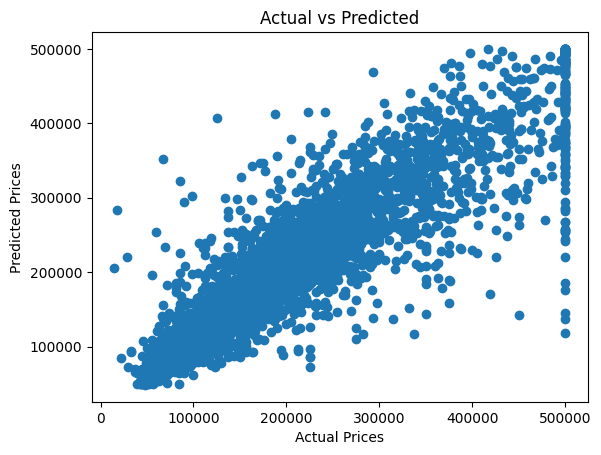

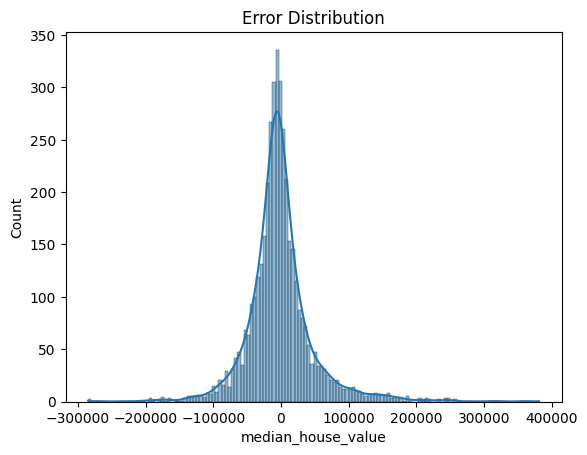

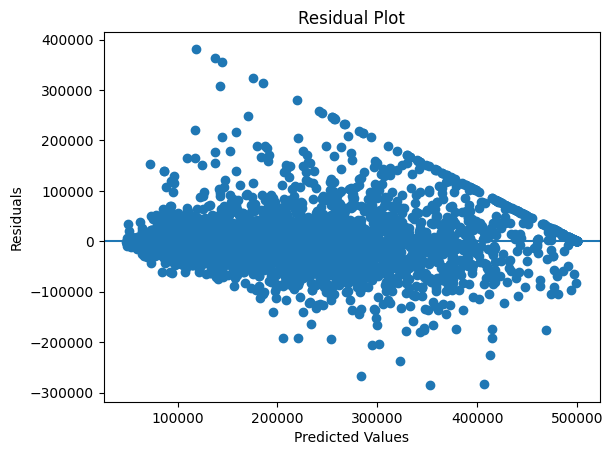


Evaluation using saved model completed


In [7]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 2. LOAD FEATURE ENGINEERED DATA
df = pd.read_csv("/kaggle/input/datasets/deepub12/featured-housing-engineering/featured_housing.csv")

print("Data Loaded")


# 3. FEATURES & TARGET

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]


# 4. TRAIN-TEST SPLIT (SAME LOGIC)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. LOAD SAVED MODEL
model = joblib.load("/kaggle/input/datasets/deepub12/house-price/house_price_model.pkl")

print("Model Loaded")


# 6. PREDICTION
y_pred = model.predict(X_test)


# 7. EVALUATION METRICS
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMODEL EVALUATION RESULTS")
print("----------------------------")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R² Score: {r2:.4f}")


# 8. ACTUAL vs PREDICTED
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


# 9. SCATTER PLOT
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()


# 10. ERROR DISTRIBUTION
errors = y_test - y_pred

plt.figure()
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()


# 11. RESIDUAL PLOT
plt.figure()
plt.scatter(y_pred, errors)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

print("\nEvaluation using saved model completed")